# Informe Ejecutivo Actuarial: Tarificación MTPL
## Fase 1: Extracción, Transformación y Análisis Exploratorio de Datos (EDA)

El presente documento documenta el proceso riguroso de extracción, limpieza y diagnóstico estadístico de la cartera de seguros de automóviles de Responsabilidad Civil (Terceros) `freMTPL2`.

### 1. Marco Teórico del Riesgo
El objetivo de este proyecto es calcular la **Prima Pura de Riesgo ($\pi$)**. Basados en el modelo colectivo de riesgo, el costo agregado esperado por póliza se define como el producto de dos variables aleatorias independientes:

$$\pi = E[S] = E[N] \times E[X]$$

Donde:
* $N$: Es la **Frecuencia** (número de reclamos), modelada típicamente mediante procesos de conteo (Poisson).
* $X$: Es la **Severidad** (costo por reclamo), modelada mediante distribuciones de colas pesadas (Gamma, Lognormal).

El análisis exploratorio a continuación tiene como propósito evaluar el poder predictivo de las variables de la póliza (edad, vehículo, historial) sobre estas dos dimensiones, con especial enfoque inicial en la severidad.

### 2. Configuración del Entorno y Librerías
Se inicializa el motor de R. A continuación, se detalla la función matemática y de sistema de cada librería empleada:

* **`CASdatasets`**: Repositorio empírico. Carga las matrices de datos en memoria.
* **`dplyr`**: Implementa el álgebra relacional para la manipulación de dataframes.
* **`corrplot`**: Motor de visualización de matrices de covarianza y correlación.
* **`ggplot2`**: Implementación estricta de la 'Gramática de los Gráficos'. Transforma datos en objetos geométricos mapeando variables a atributos estéticos (coordenadas, color, tamaño).
* **`renv`**: Crea un archivo renv.lock que guarda el estado de las librerias de R para la reproductibilidad, asegurado que las librerias se instalen en la versión utilizada por primera vez

In [1]:
# install.packages("CASdatasets", repos = "http://cas.uqam.ca/pub/R/")
library(renv)
library(CASdatasets) 
library(dplyr)       
library(corrplot)    
library(ggplot2)


Attaching package: ‘renv’

The following objects are masked from ‘package:stats’:

    embed, update

The following objects are masked from ‘package:utils’:

    history, upgrade

The following objects are masked from ‘package:base’:

    autoload, load, remove, use

Loading required package: xts
Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: survival

######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not 

### 3. Integración de Bases de Datos (ETL)
La base de frecuencia contiene la exposición al riesgo, mientras que la base de severidad registra los eventos individuales. Para una póliza $i$ con $N_i$ siniestros, el monto total $S_i$ es la suma algebraica $S_i = \sum_{j=1}^{N_i} X_{i,j}$. 

El cruce (Join) sin sumar previamente duplicaría la exposición $v$ de las pólizas con siniestros múltiples, rompiendo el supuesto de independencia temporal.

In [2]:
data("freMTPL2freq")
data("freMTPL2sev")

# Paso 1: Agregación de la severidad (S_i)
sev_agrupada <- freMTPL2sev %>%
  group_by(IDpol) %>%
  summarise(TotalClaimAmount = sum(ClaimAmount), .groups = 'drop')

# Paso 2: Cruce de bases por llave primaria
df_completo <- freMTPL2freq %>%
  left_join(sev_agrupada, by = "IDpol")

# Paso 3: Asignación de costo cero a pólizas sin siniestros
df_completo$TotalClaimAmount[is.na(df_completo$TotalClaimAmount)] <- 0

### 4. Diagnóstico de Colinealidad Estructural (Matriz de Spearman)
Para evaluar la dependencia inicial, utilizamos el **Coeficiente de Correlación de Rangos de Spearman ($\rho$)**. 

**Justificación Estadística:** El coeficiente de Pearson ($\rho_{xy} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$) asume linealidad estricta y es altamente inestable ante distribuciones de cola pesada (outliers) como las que presentan los siniestros de MTPL. Spearman, al evaluar la covarianza de los *rangos* (posiciones relativas) de las variables, captura relaciones monótonas no lineales y es robusto ante siniestros catastróficos.

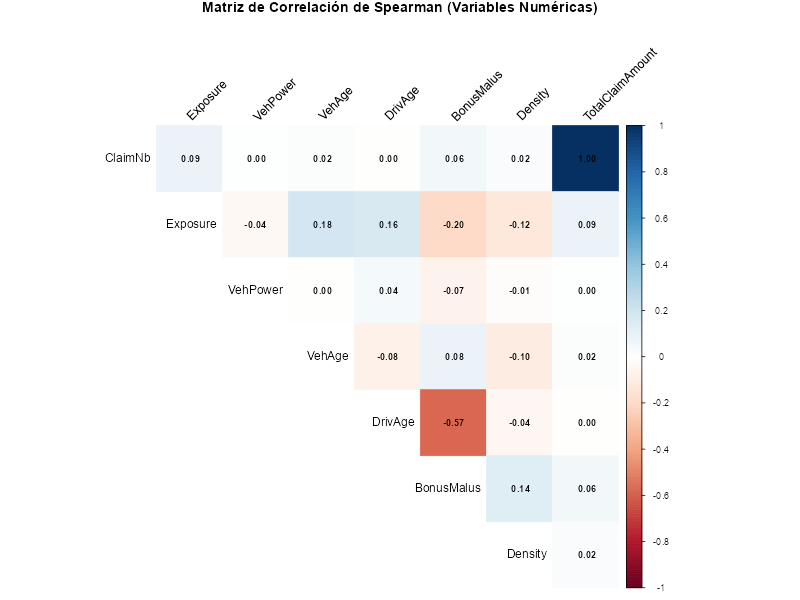

In [3]:
df_numerico <- df_completo %>%
  select(ClaimNb, Exposure, VehPower, VehAge, DrivAge, BonusMalus, Density, TotalClaimAmount)

matriz_correlacion <- cor(df_numerico, use = "pairwise.complete.obs", method = "spearman")

corrplot(matriz_correlacion, 
         method = "color", 
         type = "upper", 
         order = "original",
         addCoef.col = "black", 
         tl.col = "black", 
         tl.srt = 45, 
         diag = FALSE,
         number.cex = 0.8,
         title = "Matriz de Correlación de Spearman (Variables Numéricas)",
         mar = c(0,0,1,0))

**Interpretación de la Matriz:**
La correlación perfecta (1.00) entre `ClaimNb` y `TotalClaimAmount` es una identidad axiomática: el monto total es cero si y solo si los reclamos son cero. Para modelar la **severidad condicionada** (el costo dado que un siniestro ocurrió), es matemáticamente imperativo truncar el espacio muestral eliminando los ceros.

In [4]:
# Filtrado del espacio muestral condicionado a N > 0
df_sev_positiva <- df_completo %>%
  filter(TotalClaimAmount > 0)

# Discretización de variables continuas para análisis por cohortes de riesgo
df_sev_positiva <- df_sev_positiva %>%
  mutate(
    DrivAge_Band = cut(DrivAge, breaks = c(17, 25, 35, 45, 55, 65, 100), 
                       include.lowest = TRUE, right = FALSE),
    BM_Band = cut(BonusMalus, breaks = c(49, 60, 70, 80, 90, 100, 250), 
                  include.lowest = TRUE, right = FALSE)
  )

### 5. Análisis Visual de la Severidad Condicionada ($E[X | N > 0]$)
Se generan diagramas de caja (boxplots) sobre el logaritmo en base 10 de la severidad. La transformación logarítmica es necesaria para estabilizar la varianza heterocedástica inherente a posibles costos médicos y de reparación.

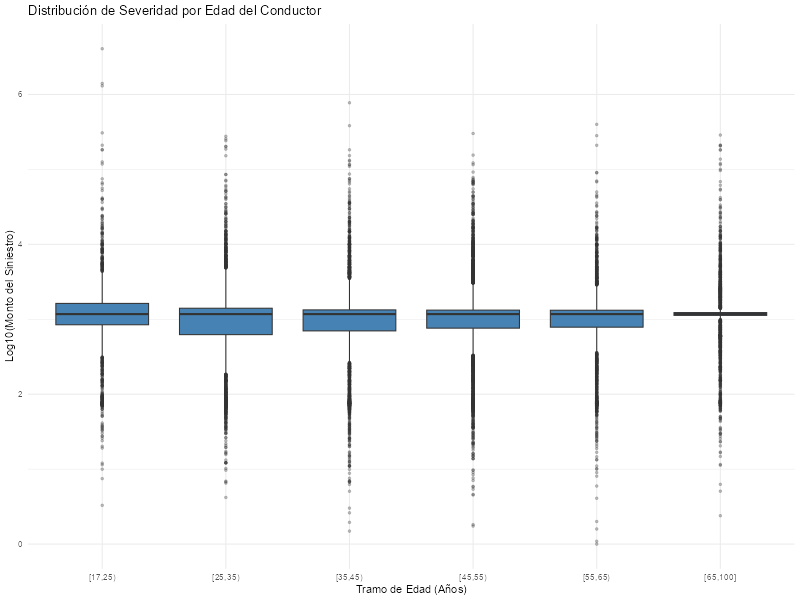

In [5]:
p_age <- ggplot(df_sev_positiva, aes(x = DrivAge_Band, y = log10(TotalClaimAmount))) +
  geom_boxplot(fill = "steelblue", outlier.alpha = 0.3, outlier.size = 1) +
  theme_minimal() +
  labs(title = "Distribución de Severidad por Edad del Conductor",
       x = "Tramo de Edad (Años)",
       y = "Log10(Monto del Siniestro)")
print(p_age)

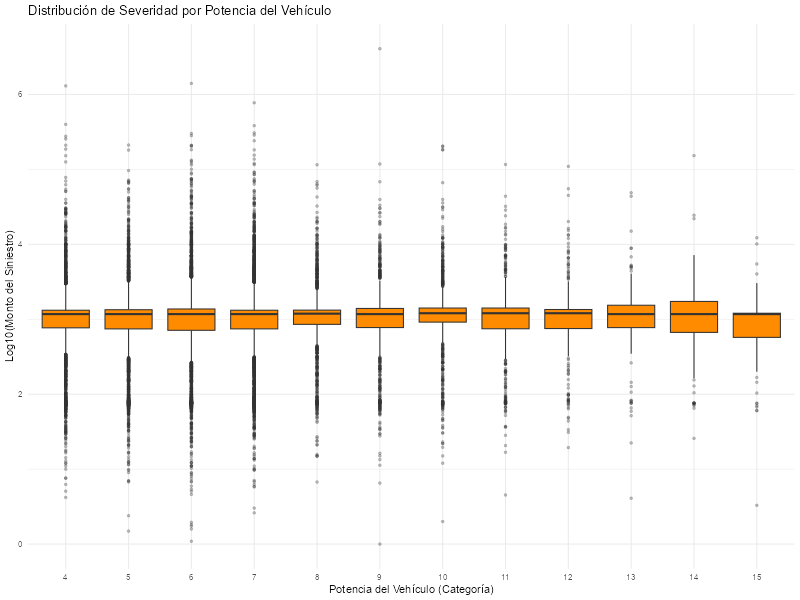

In [6]:
p_power <- ggplot(df_sev_positiva, aes(x = as.factor(VehPower), y = log10(TotalClaimAmount))) +
  geom_boxplot(fill = "darkorange", outlier.alpha = 0.3, outlier.size = 1) +
  theme_minimal() +
  labs(title = "Distribución de Severidad por Potencia del Vehículo",
       x = "Potencia del Vehículo (Categoría)",
       y = "Log10(Monto del Siniestro)")
print(p_power)

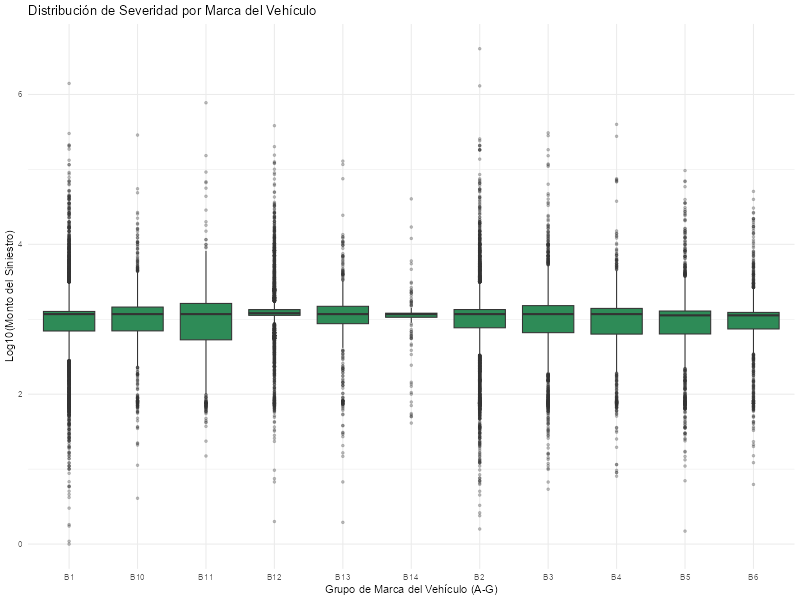

In [7]:
p_brand <- ggplot(df_sev_positiva, aes(x = VehBrand, y = log10(TotalClaimAmount))) +
  geom_boxplot(fill = "seagreen", outlier.alpha = 0.3, outlier.size = 1) +
  theme_minimal() +
  labs(title = "Distribución de Severidad por Marca del Vehículo",
       x = "Grupo de Marca del Vehículo (A-G)",
       y = "Log10(Monto del Siniestro)")
print(p_brand)

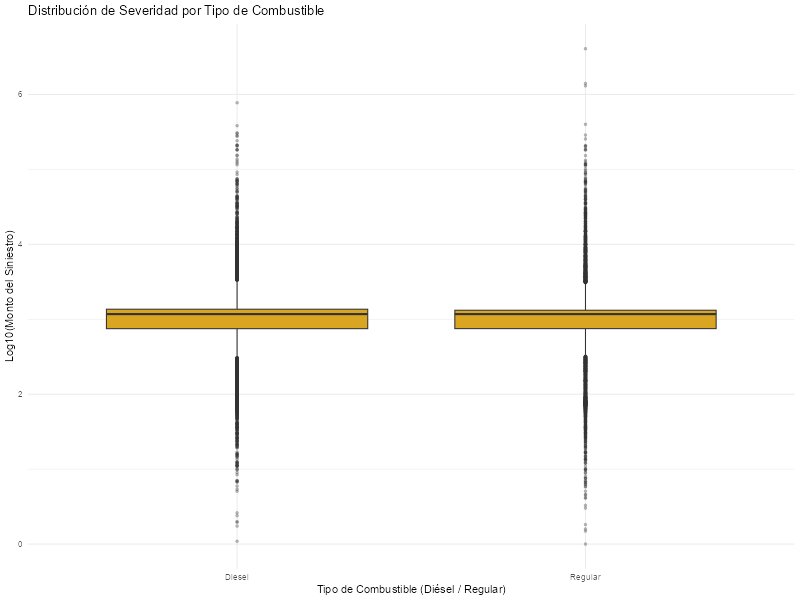

In [8]:
p_gas <- ggplot(df_sev_positiva, aes(x = VehGas, y = log10(TotalClaimAmount))) +
  geom_boxplot(fill = "goldenrod", outlier.alpha = 0.3, outlier.size = 1) +
  theme_minimal() +
  labs(title = "Distribución de Severidad por Tipo de Combustible",
       x = "Tipo de Combustible (Diésel / Regular)",
       y = "Log10(Monto del Siniestro)")
print(p_gas)

### Conclusión Ejecutiva de la Fase Exploratoria
El análisis visual exhaustivo sobre los cuantiles, medianas (línea central del diagrama de cajas) y dispersión intercuartílica demuestra una **ausencia de varianza explicable significativa** a través de las características demográficas y del vehículo.

**Decisión Actuarial:** La severidad de los reclamos en esta cartera es predominantemente estocástica. Un choque causado por un conductor joven tiene un costo esperado estadísticamente indistinguible de un choque causado por un conductor maduro. En consecuencia, el modelo predictivo final asignará un parámetro de prima pura base constante para la severidad que sera la esperanza completa de la severidad reportada previamente, delegando el peso de la segmentación tarifaria exclusivamente a la probabilidad de ocurrencia (Frecuencia).

### 6. Exportación de Datos (Checkpointing)
Garantizamos la inmutabilidad y reproducibilidad del estudio exportando las matrices resultantes al disco, preparándolas para la ingesta en el motor de Python.

In [9]:
write.csv(df_sev_positiva, "df_sev_positiva_export.csv", row.names = FALSE)
write.csv(df_completo, "df_completo_export.csv", row.names = FALSE)